In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [17]:
df = pd.read_csv("heart.csv")
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())
print(df['target'].value_counts())

Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
target
1    165
0    138
Name: count, dtype: int64


Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


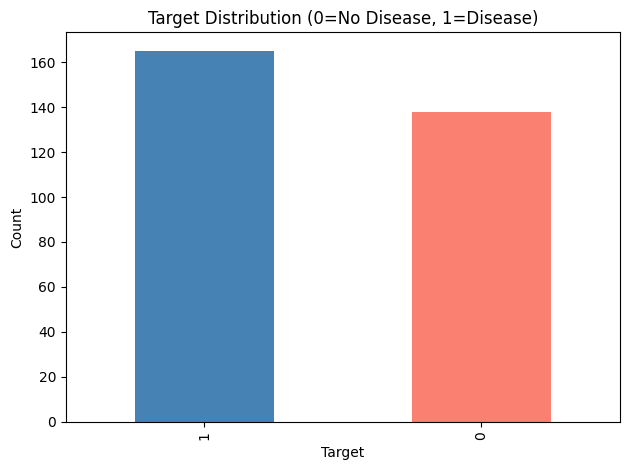

In [18]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

# Class distribution
df['target'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title("Target Distribution (0=No Disease, 1=Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [19]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (242, 13)
Test size:  (61, 13)


In [20]:
# 1. Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# 2. K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 3. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [21]:
models = {
    "Logistic Regression": lr,
    "KNN": knn,
    "Decision Tree": dt
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    results.append({"Algorithm": name, "Accuracy": f"{acc*100:.2f}%", "F1 Score": round(f1, 2)})
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

# Comparison Table
results_df = pd.DataFrame(results)
print("\n=== Comparison Table ===")
print(results_df.to_string(index=False))


Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61


KNN
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


Decision Tree
              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75

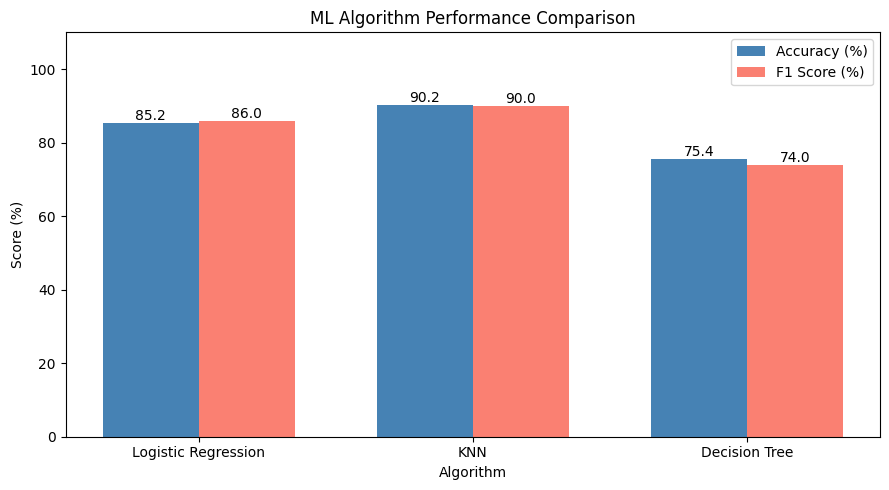

In [22]:
names = [r["Algorithm"] for r in results]
accs  = [float(r["Accuracy"].replace('%','')) for r in results]
f1s   = [r["F1 Score"] for r in results]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy (%)', color='steelblue')
bars2 = ax.bar(x + width/2, [f*100 for f in f1s], width, label='F1 Score (%)', color='salmon')

ax.set_xlabel('Algorithm')
ax.set_ylabel('Score (%)')
ax.set_title('ML Algorithm Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_ylim(0, 110)

for bar in bars1: ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), ha='center', va='bottom')
for bar in bars2: ax.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [23]:
best = max(results, key=lambda x: float(x["Accuracy"].replace('%','')))
print("=== CONCLUSION ===")
print(f"Best Algorithm : {best['Algorithm']}")
print(f"Best Accuracy  : {best['Accuracy']}")
print(f"Best F1 Score  : {best['F1 Score']}")
print("""
Justification:
- Logistic Regression is simple and works well for linearly separable data.
- KNN is non-parametric and captures local patterns but is sensitive to scale.
- Decision Tree can model non-linear boundaries but may overfit.
The best model achieves the highest accuracy and F1-score on the test set,
making it the most suitable for predicting heart disease in this dataset.
""")

=== CONCLUSION ===
Best Algorithm : KNN
Best Accuracy  : 90.16%
Best F1 Score  : 0.9

Justification:
- Logistic Regression is simple and works well for linearly separable data.
- KNN is non-parametric and captures local patterns but is sensitive to scale.
- Decision Tree can model non-linear boundaries but may overfit.
The best model achieves the highest accuracy and F1-score on the test set,
making it the most suitable for predicting heart disease in this dataset.

